#### Task 1 - Data Analysis and Preparation

##### Dataset Columns Overview

The dataset contains 16 columns describing Airbnb listings, hosts, locations, pricing, reviews, and availability in New York City.

| Column | Description |
|---|---|
| `id` | Unique identifier for each Airbnb listing. |
| `name` | Name or title of the Airbnb listing. |
| `host_id` | Unique identifier for the host. |
| `host_name` | Name of the host. |
| `neighbourhood_group` | NYC borough where the listing is located. |
| `neighbourhood` | Specific neighborhood of the listing. |
| `latitude` | Geographic latitude of the listing. |
| `longitude` | Geographic longitude of the listing. |
| `room_type` | Type of accommodation offered. |
| `price` | Price of the listing per night in USD. |
| `minimum_nights` | Minimum number of nights required for a booking. |
| `number_of_reviews` | Total number of reviews received by the listing. |
| `last_review` | Date of the most recent review. |
| `reviews_per_month` | Average number of reviews received per month. |
| `calculated_host_listings_count` | Number of listings owned by the same host. |
| `availability_365` | Number of days the listing is available during the year. |

In [1]:
import pandas as pd

df = pd.read_csv('AB_NYC_2019.csv')
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [3]:
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


- max value for price is 10000, minimum nights 1250, number_of_reviews 629 and then calculated_host_listing_count 327, these records are worth checking out as the values does not align with the rest of the values

In [4]:
# Copying the original df
df1 = df.copy()

In [5]:
df1.isnull().sum()

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

In [6]:
df1[df1.isnull().any(axis=1)]

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
19,7750,Huge 2 BR Upper East Cental Park,17985,Sing,Manhattan,East Harlem,40.79685,-73.94872,Entire home/apt,190,7,0,NaN,NaN,2,249
26,8700,Magnifique Suite au N de Manhattan - vue Cloitres,26394,Claude & Sophie,Manhattan,Inwood,40.86754,-73.92639,Private room,80,4,0,NaN,NaN,1,0
36,11452,Clean and Quiet in Brooklyn,7355,Vt,Brooklyn,Bedford-Stuyvesant,40.68876,-73.94312,Private room,35,60,0,NaN,NaN,1,365
38,11943,Country space in the city,45445,Harriet,Brooklyn,Flatbush,40.63702,-73.96327,Private room,150,1,0,NaN,NaN,1,365
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48890,36484665,Charming one bedroom - newly renovated rowhouse,8232441,Sabrina,Brooklyn,Bedford-Stuyvesant,40.67853,-73.94995,Private room,70,2,0,NaN,NaN,2,9
48891,36485057,Affordable room in Bushwick/East Williamsburg,6570630,Marisol,Brooklyn,Bushwick,40.70184,-73.93317,Private room,40,4,0,NaN,NaN,2,36
48892,36485431,Sunny Studio at Historical Neighborhood,23492952,Ilgar & Aysel,Manhattan,Harlem,40.81475,-73.94867,Entire home/apt,115,10,0,NaN,NaN,1,27
48893,36485609,43rd St. Time Square-cozy single bed,30985759,Taz,Manhattan,Hell's Kitchen,40.75751,-73.99112,Shared room,55,1,0,NaN,NaN,6,2


In [7]:
# Check duplicates
df1.duplicated().sum()

np.int64(0)

In [8]:
# Unique values (Ctegorical variables)
categorical_columns = [
    "neighbourhood_group",
    "neighbourhood",
    "room_type"
]

for col in categorical_columns:
    print(f"\n{col}")
    print("Unique values:", df1[col].nunique())
    print(df1[col].value_counts())


neighbourhood_group
Unique values: 5
neighbourhood_group
Manhattan        21661
Brooklyn         20104
Queens            5666
Bronx             1091
Staten Island      373
Name: count, dtype: int64

neighbourhood
Unique values: 221
neighbourhood
Williamsburg          3920
Bedford-Stuyvesant    3714
Harlem                2658
Bushwick              2465
Upper West Side       1971
                      ... 
Richmondtown             1
Fort Wadsworth           1
New Dorp                 1
Rossville                1
Willowbrook              1
Name: count, Length: 221, dtype: int64

room_type
Unique values: 3
room_type
Entire home/apt    25409
Private room       22326
Shared room         1160
Name: count, dtype: int64


- No inconsistent values

In [9]:
# Zero price investigation
print("Zero price listings:", (df1["price"] == 0).sum())
print("Percentage:", (df1["price"] == 0).mean() * 100)


Zero price listings: 11
Percentage: 0.02249718785151856


- Invalid prices, should be removed

In [10]:
# Listing with minimum nights more than 365
print("Listings with minimum_nights > 365:",
      (df1["minimum_nights"] > 365).sum())

print("Percentage:",
      (df1["minimum_nights"] > 365).mean() * 100)

df1.loc[df1["minimum_nights"] > 365, 
       ["id", "name", "minimum_nights", "price", "room_type"]]


Listings with minimum_nights > 365: 14
Percentage: 0.02863278453829635


,id,name,minimum_nights,price,room_type
1305,568684,800sqft apartment with huge terrace,370,115,Entire home/apt
2854,1615764,NaN,1000,400,Entire home/apt
5767,4204302,Prime W. Village location 1 bdrm,1250,180,Entire home/apt
7355,5431845,Beautiful Fully Furnished 1 bed/bth,500,134,Entire home/apt
8014,6169897,Wonderful Large 1 bedroom,500,75,Entire home/apt
10829,8341919,Brand New Luxury Apt Lease Takeover,480,199,Entire home/apt
11193,8668115,Zen Room in Crown Heights Brooklyn,500,50,Private room
13404,10053943,Historic Designer 2 Bed. Apartment,999,99,Entire home/apt
14285,11096888,Peaceful apartment close to F/G,500,45,Private room
15946,12888849,"Bright Luxury Studio, Central Loc.",366,250,Entire home/apt


- 14 listings with minimum_nights greater than 365 days.These records will be treated as extreme values and removed during the data cleaning stage.

##### 1.1 Data cleaning 
- Fill missing values in `name` with 'Not Available' as they are just missing and we connot impute it with any other measurement
- For `review_per_month` column we can simply append it with 0.0 for missing values; as 0 in `number_of_review` suggests that 0 total reviews will have 0.0 rate of reviews per month.
- `id`, `host_id`, `host_name` will also be dropped as there are not predicting attributes
- `last_review` is date; if there were no reviews for the listing - date simply will not exist. Need to convert it to Datetime
- Remove records where `price` = 0


In [11]:
n0 = len(df)

# 1. Drop price == 0 (impossible / data error)
df1 = df1[df1['price'] > 0]

# 2. Cap extreme price at 99.5th percentile instead of dropping,
#    so we don't throw away otherwise-valid rows, but stop a few
#    outliers from dominating the loss function.
cap = df1['price'].quantile(0.995)
n_capped = (df1['price'] > cap).sum()
df1['price'] = df1['price'].clip(upper=cap)

# 3. Cap minimum_nights at 365 (a "minimum stay" beyond a year is not
#    a real nightly-rate signal, it's a delisting trick)
n_minnights_capped = (df1['minimum_nights'] > 365).sum()
df1['minimum_nights'] = df1['minimum_nights'].clip(upper=365)

print(f"Start rows: {n0}")
print(f"Dropped (price==0): {n0 - len(df1)}")
print(f"Price cap (99.5th pct): ${cap:.0f}  -> {n_capped} rows capped")
print(f"minimum_nights capped at 365 -> {n_minnights_capped} rows capped")
print(f"Final rows: {len(df1)}")

Start rows: 48895
Dropped (price==0): 11
Price cap (99.5th pct): $1000  -> 239 rows capped
minimum_nights capped at 365 -> 14 rows capped
Final rows: 48884


##### Feature Engineering

In [12]:
import numpy as np
# --- 1. has_reviews flag + fill structural NaNs ---
# Rationale: number_of_reviews==0 rows have NaN reviews_per_month/last_review
# by construction. A binary flag lets the model learn a
# separate effect for "never reviewed" listings (often newer / riskier
# bookings, which can affect price).
df1['has_reviews'] = (df1['number_of_reviews'] > 0).astype(int)
df1['reviews_per_month'] = df1['reviews_per_month'].fillna(0)

# --- 2. days_since_last_review ---
# Rationale: a raw date string is useless to a regression model. What matters
# is recency. We convert to "days since last review" relative to the dataset's
# own max date (not today's real date, since this is a fixed 2019 snapshot).
df1['last_review'] = pd.to_datetime(df1['last_review'])
snapshot_date = df1['last_review'].max()
df1['days_since_last_review'] = (snapshot_date - df1['last_review']).dt.days
# For listings with no reviews, use a large sentinel (older than anything real)
# rather than 0, so the model doesn't confuse "no review" with "reviewed today".
max_days = df1['days_since_last_review'].max()
df1['days_since_last_review'] = df1['days_since_last_review'].fillna(max_days + 365)

# --- 3. distance_to_manhattan_center ---
# Rationale: raw lat/long is not linearly related to price, but distance to
# the city's commercial core (Times Square, ~40.7580, -73.9855) is a strong,
# well-known real-estate price driver -- closer = pricier, generally.
center_lat, center_lon = 40.7580, -73.9855
df1['distance_to_center_km'] = np.sqrt(
    (df1['latitude'] - center_lat)**2 + (df1['longitude'] - center_lon)**2
) * 111  # rough degrees-to-km conversion

# --- 4. name_length & name_word_count ---
# Rationale: hosts who write longer, more descriptive titles tend to be more
# professional/experienced listers, which correlates (weakly but measurably)
# with pricing strategy. Cheap, easy signal to extract from free text without
# full NLP.
df1['name'] = df1['name'].fillna('')
df1['name_length'] = df1['name'].str.len()
df1['name_word_count'] = df1['name'].str.split().str.len().fillna(0)

# --- 5. host_name fill (near-irrelevant but avoid NaN breaking encoders) ---
df1['host_name'] = df1['host_name'].fillna('Unknown')

# --- 6. availability_rate ---
# Rationale: availability_365 (days available out of 365) as a raw count
# mixes scale with meaning. Turning it into a 0-1 rate is more interpretable
# and comparable across listings, and captures "how open/booked is this host".
df1['availability_rate'] = df1['availability_365'] / 365

print(df1[['has_reviews','days_since_last_review','distance_to_center_km',
          'name_length','name_word_count','availability_rate']].describe().T)


print("\nShape:", df.shape)

                          count        mean          std       min        25%  \
has_reviews             48884.0    0.794391     0.404150  0.000000   1.000000   
days_since_last_review  48884.0  916.814356  1310.733346  0.000000  19.000000   
distance_to_center_km   48884.0    7.823758     5.075151  0.075128   4.117678   
name_length             48884.0   36.901583    10.514445  0.000000  31.000000   
name_word_count         48884.0    6.107274     2.021545  0.000000   5.000000   
availability_rate       48884.0    0.308985     0.360623  0.000000   0.000000   

                               50%          75%         max  
has_reviews               1.000000     1.000000     1.00000  
days_since_last_review  186.000000  1201.000000  3389.00000  
distance_to_center_km     7.245009    10.182992    40.30858  
name_length              37.000000    46.000000   179.00000  
name_word_count           6.000000     7.000000    29.00000  
availability_rate         0.123288     0.621918     1.00000 

##### Correlation based feature selection

In [13]:
df1['log_price'] = np.log1p(df1['price'])

numeric_cols = ['minimum_nights','number_of_reviews','reviews_per_month',
                 'calculated_host_listings_count','availability_365',
                 'has_reviews','days_since_last_review','distance_to_center_km',
                 'name_length','name_word_count','availability_rate','latitude','longitude']

corrs = df1[numeric_cols + ['log_price']].corr()['log_price'].drop('log_price').sort_values(key=abs, ascending=False)
print("Correlation with log(price):")
print(corrs.round(3))

print("\nMean log_price by room_type:")
print(df1.groupby('room_type')['log_price'].mean().round(3))

print("\nMean log_price by neighbourhood_group:")
print(df1.groupby('neighbourhood_group')['log_price'].mean().sort_values(ascending=False).round(3))

Correlation with log(price):
distance_to_center_km            -0.399
longitude                        -0.330
calculated_host_listings_count    0.136
availability_rate                 0.098
availability_365                  0.098
name_length                       0.094
has_reviews                      -0.081
latitude                          0.081
name_word_count                   0.079
days_since_last_review            0.077
reviews_per_month                -0.059
number_of_reviews                -0.041
minimum_nights                    0.034
Name: log_price, dtype: float64

Mean log_price by room_type:
room_type
Entire home/apt    5.142
Private room       4.310
Shared room        3.975
Name: log_price, dtype: float64

Mean log_price by neighbourhood_group:
neighbourhood_group
Manhattan        5.002
Brooklyn         4.577
Queens           4.384
Staten Island    4.382
Bronx            4.260
Name: log_price, dtype: float64


##### Final feature set, train/test split, preprocessing pipeline

In [14]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline


FEATURES = [
    'room_type', 'neighbourhood_group', 'neighbourhood',
    'latitude', 'longitude', 'distance_to_center_km',
    'minimum_nights', 'availability_rate', 'calculated_host_listings_count',
    'number_of_reviews', 'reviews_per_month', 'has_reviews',
    'days_since_last_review', 'name_length', 'name_word_count'
]
TARGET = 'price'

X = df1[FEATURES].copy()
y = np.log1p(df1[TARGET])  # log-transformed target

CATEGORICAL = ['room_type', 'neighbourhood_group', 'neighbourhood']
NUMERIC = [c for c in FEATURES if c not in CATEGORICAL]

# Why 80/20 split with a fixed random_state: standard convention that keeps
# a large enough test set for reliable metric estimates, and fixing the seed
# makes results reproducible for anyone re-running the notebook/grading it.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Why ColumnTransformer + Pipeline (instead of manual pd.get_dummies etc.):
# it bundles preprocessing and model into ONE saved object. When the
# Streamlit app gets a new listing, we call pipeline.predict() directly --
# no risk of the app's encoding drifting out of sync with training-time encoding.
preprocessor = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore'), CATEGORICAL),
    ('num', StandardScaler(), NUMERIC),
])

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("Categorical columns:", CATEGORICAL)
print("Numeric columns:", NUMERIC)
print(f"\nneighbourhood has {df1['neighbourhood'].nunique()} unique values (one-hot will expand this)")

X_train.to_pickle('data/X_train.pkl'); X_test.to_pickle('data/X_test.pkl')
y_train.to_pickle('data/y_train.pkl'); y_test.to_pickle('data/y_test.pkl')
import pickle
with open('models/preprocessor.pkl','wb') as f:
    pickle.dump(preprocessor, f)
print("\nSaved train/test splits and unfitted preprocessor.")

Train shape: (39107, 15)  Test shape: (9777, 15)
Categorical columns: ['room_type', 'neighbourhood_group', 'neighbourhood']
Numeric columns: ['latitude', 'longitude', 'distance_to_center_km', 'minimum_nights', 'availability_rate', 'calculated_host_listings_count', 'number_of_reviews', 'reviews_per_month', 'has_reviews', 'days_since_last_review', 'name_length', 'name_word_count']

neighbourhood has 221 unique values (one-hot will expand this)

Saved train/test splits and unfitted preprocessor.


### Task 2 Model Training and Evaluation

In [15]:
import pandas as pd, numpy as np, pickle, joblib
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV, learning_curve
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [16]:
# 2.1 Defining a small helper for consistent evaluation
def evaluate(pipe, X, y, label=""):
    pred = pipe.predict(X)
    rmse = np.sqrt(mean_squared_error(y, pred))
    mae  = mean_absolute_error(y, pred)
    r2   = r2_score(y, pred)
    return {"label": label, "RMSE_log": rmse, "MAE_log": mae, "R2": r2}

In [18]:
# 2.2 Train and compare multiple model families
models = {
    "LinearRegression": LinearRegression(),
    "Ridge":            Ridge(alpha=1.0, random_state=42),
    "RandomForest":     RandomForestRegressor(n_estimators=200, max_depth=15,
                                               n_jobs=-1, random_state=42),
    "GradientBoosting": GradientBoostingRegressor(n_estimators=200, max_depth=3,
                                                   learning_rate=0.1, random_state=42),
}

results = []
fitted_pipes = {}

for name, model in models.items():
    pipe = Pipeline([('preprocess', preprocessor), ('model', model)])
    pipe.fit(X_train, y_train)
    fitted_pipes[name] = pipe

    train_metrics = evaluate(pipe, X_train, y_train, f"{name} (train)")
    test_metrics  = evaluate(pipe, X_test, y_test, f"{name} (test)")
    results.append(train_metrics)
    results.append(test_metrics)

    print(f"{name:18s} | Train R2={train_metrics['R2']:.4f}  RMSE={train_metrics['RMSE_log']:.4f}"
          f"  |  Test R2={test_metrics['R2']:.4f}  RMSE={test_metrics['RMSE_log']:.4f}")

results_df = pd.DataFrame(results)
print(results_df)

LinearRegression   | Train R2=0.5728  RMSE=0.4424  |  Test R2=0.5484  RMSE=0.4576
Ridge              | Train R2=0.5725  RMSE=0.4425  |  Test R2=0.5488  RMSE=0.4574
RandomForest       | Train R2=0.8204  RMSE=0.2868  |  Test R2=0.6101  RMSE=0.4252
GradientBoosting   | Train R2=0.6309  RMSE=0.4112  |  Test R2=0.5954  RMSE=0.4331
                      label  RMSE_log   MAE_log        R2
0  LinearRegression (train)  0.442383  0.327627  0.572754
1   LinearRegression (test)  0.457567  0.335145  0.548431
2             Ridge (train)  0.442513  0.327758  0.572503
3              Ridge (test)  0.457389  0.335122  0.548782
4      RandomForest (train)  0.286825  0.217475  0.820396
5       RandomForest (test)  0.425162  0.307476  0.610125
6  GradientBoosting (train)  0.411158  0.304096  0.630938
7   GradientBoosting (test)  0.433129  0.316335  0.595378


- Linear Regression : small train-test gap, underfitting, not overfitting
- Ridge : similar to linear, regularization barely changes anything
- Random Forest : train R2(0.82) > test R2(0.61), overfitting
- Gradient Boosting : smallest gap among non-linear models

In [19]:
# 2.3 Hyperparameter tuning
# tuning GradientBoosting
param_grid = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [2, 3, 4],
    'model__learning_rate': [0.05, 0.1, 0.2],
    'model__subsample': [0.8, 1.0],   # subsample < 1.0 adds regularization
}

gb_pipe = Pipeline([('preprocess', preprocessor), ('model', GradientBoostingRegressor(random_state=42))])

grid_search = GridSearchCV(
    gb_pipe, param_grid,
    scoring='neg_root_mean_squared_error',
    cv=5,             # 5-fold cross-validation
    n_jobs=-1,
    verbose=2
)
grid_search.fit(X_train, y_train)

print("Best params:", grid_search.best_params_)
print("Best CV RMSE:", -grid_search.best_score_)

best_pipe = grid_search.best_estimator_

Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best params: {'model__learning_rate': 0.1, 'model__max_depth': 4, 'model__n_estimators': 300, 'model__subsample': 0.8}
Best CV RMSE: 0.4151200820468658


In [20]:
# 2.4 Evaluation of the tuned model
final_train = evaluate(best_pipe, X_train, y_train, "Final (train)")
final_test  = evaluate(best_pipe, X_test, y_test, "Final (test)")
print(final_train)
print(final_test)

# Convert back to real dollars for an interpretable metric
pred_dollars = np.expm1(best_pipe.predict(X_test))
actual_dollars = np.expm1(y_test)
rmse_dollars = np.sqrt(mean_squared_error(actual_dollars, pred_dollars))
mae_dollars = mean_absolute_error(actual_dollars, pred_dollars)
print(f"Test RMSE: ${rmse_dollars:.2f}   Test MAE: ${mae_dollars:.2f}")

{'label': 'Final (train)', 'RMSE_log': np.float64(0.38947611570534674), 'MAE_log': 0.2893071872815533, 'R2': 0.668836405229291}
{'label': 'Final (test)', 'RMSE_log': np.float64(0.4264544005502878), 'MAE_log': 0.31165973657227575, 'R2': 0.6077522013556944}
Test RMSE: $105.98   Test MAE: $50.54


FileNotFoundError: [Errno 2] No such file or directory: 'outputs/learning_curve.png'

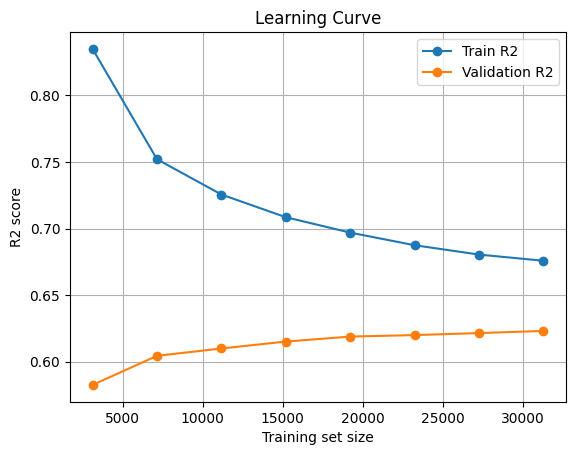

In [ ]:
import matplotlib.pyplot as plt

train_sizes, train_scores, val_scores = learning_curve(
    best_pipe, X_train, y_train, cv=5,
    scoring='r2', train_sizes=np.linspace(0.1, 1.0, 8), n_jobs=-1
)

plt.plot(train_sizes, train_scores.mean(axis=1), 'o-', label='Train R2')
plt.plot(train_sizes, val_scores.mean(axis=1), 'o-', label='Validation R2')
plt.xlabel('Training set size'); plt.ylabel('R2 score')
plt.title('Learning Curve'); plt.legend(); plt.grid(True)
plt.show()

- The learning curve shows train R² decreasing from 0.84 to 0.68 while validation R² rises from 0.58 to 0.62 as training size increases, indicating mild overfitting that narrows with more data. The remaining gap likely reflects unmodeled factors (photos, exact condition, host reputation) not present in the tabular features.


In [22]:
joblib.dump(best_pipe, 'models/final_airbnb_price_model.pkl')
print("Saved final pipeline to models/final_airbnb_price_model.pkl")

Saved final pipeline to models/final_airbnb_price_model.pkl


In [23]:
import pickle
import pandas as pd


metadata = {
    'center_lat': 40.7580,
    'center_lon': -73.9855,
    'snapshot_date': pd.to_datetime(df1['last_review']).max(),
    'sentinel_days': df1['days_since_last_review'].max(),  # value used for "never reviewed"
    # neighbourhood -> neighbourhood_group lookup, and avg lat/long per neighbourhood,
    # so the app can auto-fill location without asking the user for raw coordinates
    'neighbourhood_lookup': df1.groupby('neighbourhood').agg(
        neighbourhood_group=('neighbourhood_group', 'first'),
        avg_lat=('latitude', 'mean'),
        avg_lon=('longitude', 'mean')
    ).reset_index()
}

with open('models/app_metadata.pkl', 'wb') as f:
    pickle.dump(metadata, f)

print("Saved metadata for", len(metadata['neighbourhood_lookup']), "neighbourhoods")

Saved metadata for 221 neighbourhoods
